# 04 — Model

The single, growing model notebook. Same temporal train/test split throughout (train up to mid-2024, test after) so every version is comparable to every earlier one. One `fit_and_evaluate()` helper is reused for each version — adding a new feature here after `03_features.ipynb` grows means adding one line, not copy-pasting a new fitting cell.

**Reading the metrics, in plain terms:**
- **Test R²** — how much of the price variation the model explains on sales it never saw during training. 0 = no better than guessing the average; 1 = perfect.
- **MdAPE** (median absolute % error) — typical error size. If MdAPE is 15%, half of predictions were off by less than 15% of the true price, half by more.
- **PPE10** — the fraction of predictions that landed within 10% of the true price. The industry standard way to grade an automated valuation model.

In [1]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_INTERIM
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_parquet(DATA_INTERIM / "sefton_features.parquet")
df["log_price"] = np.log(df["price"])
df["log_price_adj"] = np.log(df["price_adjusted"])
df["log_area"] = np.log(df["total_floor_area"])
df["log_relsize"] = np.log(df["relative_size"])
df["dist_to_beach_km"] = df["dist_to_beach_m"] / 1000

split_date = pd.Timestamp("2024-07-01")
print(f"{len(df):,} rows loaded")

61,310 rows loaded


## The reusable fit-and-evaluate helper

Takes a target column (raw price or inflation-adjusted price) and a list of feature columns, fits on the training split, scores on the test split, and prints the same set of metrics every time so versions are always directly comparable.

In [2]:
def fit_and_evaluate(feature_cols, label, target_col="log_price_adj"):
    data = df.dropna(subset=feature_cols + [target_col, "date_of_transfer"])
    train = data[data["date_of_transfer"] < split_date]
    test = data[data["date_of_transfer"] >= split_date]

    X_train = sm.add_constant(train[feature_cols])
    model = sm.OLS(train[target_col], X_train).fit()

    X_test = sm.add_constant(test[feature_cols])
    pred_log = model.predict(X_test)
    actual = np.exp(test[target_col])
    pred = np.exp(pred_log)

    ape = (pred - actual).abs() / actual
    mdape = ape.median()
    ppe10 = (ape <= 0.10).mean()
    ss_res = ((test[target_col] - pred_log) ** 2).sum()
    ss_tot = ((test[target_col] - test[target_col].mean()) ** 2).sum()
    test_r2 = 1 - ss_res / ss_tot

    print(f"--- {label} ---")
    print(f"n = {len(train):,} train / {len(test):,} test")
    print(f"Train R2:  {model.rsquared:.3f}")
    print(f"Test R2:   {test_r2:.3f}")
    print(f"Test MdAPE: {mdape:.1%}")
    print(f"Test PPE10: {ppe10:.1%}")
    print()
    return model, pred, {"mdape": mdape, "ppe10": ppe10, "test_r2": test_r2}


## Model versions, in order built

- **v0 — Phase 1 baseline**: floor area only, *no* inflation adjustment. Kept as the fixed reference point everything else is measured against (test R² was ≈0 here — this is what exposed the need for the fix below).
- **v1**: same, but inflation-adjusted. Isolates how much that one fix was worth.
- **v2**: adds `relative_size` (house size vs its 15 nearest neighbours).
- **v3**: adds house type and coastal distance.

In [3]:
built_form_dummies = [c for c in df.columns if c.startswith("type_")]

m0, p0, s0 = fit_and_evaluate(["log_area"], "v0: floor area only (NOT inflation-adjusted)", target_col="log_price")
m1, p1, s1 = fit_and_evaluate(["log_area"], "v1: floor area only (inflation-adjusted)")
m2, p2, s2 = fit_and_evaluate(["log_area", "log_relsize"], "v2: + relative_size")
m3, p3, s3 = fit_and_evaluate(["log_area", "log_relsize", "dist_to_beach_km"] + built_form_dummies, "v3: + house type + coastal distance")

--- v0: floor area only (NOT inflation-adjusted) ---
n = 46,789 train / 6,139 test
Train R2:  0.452
Test R2:   -0.009
Test MdAPE: 33.6%
Test PPE10: 10.0%



--- v1: floor area only (inflation-adjusted) ---
n = 46,789 train / 6,139 test
Train R2:  0.482
Test R2:   0.492
Test MdAPE: 20.1%
Test PPE10: 25.5%

--- v2: + relative_size ---
n = 46,789 train / 6,139 test
Train R2:  0.542
Test R2:   0.560
Test MdAPE: 18.0%
Test PPE10: 28.4%



--- v3: + house type + coastal distance ---
n = 46,789 train / 6,139 test
Train R2:  0.656
Test R2:   0.668
Test MdAPE: 15.1%
Test PPE10: 34.7%



## Progress so far

One table, every version, so the next feature added to `03_features.ipynb` has an obvious bar to clear.

In [4]:
summary = pd.DataFrame({
    "version": ["v0: baseline (no HPI fix)", "v1: + HPI adjustment", "v2: + relative_size", "v3: + house type + coastal"],
    "test_r2": [s0["test_r2"], s1["test_r2"], s2["test_r2"], s3["test_r2"]],
    "mdape": [s0["mdape"], s1["mdape"], s2["mdape"], s3["mdape"]],
    "ppe10": [s0["ppe10"], s1["ppe10"], s2["ppe10"], s3["ppe10"]],
}).set_index("version")
print(summary.to_string(formatters={"mdape": "{:.1%}".format, "ppe10": "{:.1%}".format, "test_r2": "{:.3f}".format}))

                           test_r2 mdape ppe10
version                                       
v0: baseline (no HPI fix)   -0.009 33.6% 10.0%
v1: + HPI adjustment         0.492 20.1% 25.5%
v2: + relative_size          0.560 18.0% 28.4%
v3: + house type + coastal   0.668 15.1% 34.7%


## What v3 is actually basing predictions on

OLS coefficients on a log-log model translate to "percent change in price per unit change in the feature" — useful for sanity-checking that the model has learned something sensible, not just a black box.

In [5]:
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:          log_price_adj   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                 1.274e+04
Date:                Sat, 08 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:11:37   Log-Likelihood:                -12108.
No. Observations:               46789   AIC:                         2.423e+04
Df Residuals:                   46781   BIC:                         2.430e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.1189      0

## Stratified check: does relative_size help most where floor area alone struggles?

The original hypothesis (plan Part 2): on uniform-stock streets, plain floor area stops predicting price at all. `relative_size` was meant to rescue exactly that case. Comparing v1 (no relative_size) against v2 (with it), split by how much floor-area variety each area has.

In [6]:
eval_df = df.dropna(subset=["log_area", "log_relsize", "log_price_adj", "date_of_transfer"])
test_eval = eval_df[eval_df["date_of_transfer"] >= split_date].copy()
test_eval["postcode_district"] = test_eval["postcode"].str.split(" ").str[0]

area_variance = eval_df.assign(postcode_district=eval_df["postcode"].str.split(" ").str[0]) \
    .groupby("postcode_district")["total_floor_area"].std()
test_eval["area_variance_tier"] = pd.qcut(
    test_eval["postcode_district"].map(area_variance), q=3, labels=["low", "medium", "high"]
)

test_eval["pred_v1"] = p1.reindex(test_eval.index)
test_eval["pred_v2"] = p2.reindex(test_eval.index)
test_eval["ape_v1"] = (test_eval["pred_v1"] - test_eval["price_adjusted"]).abs() / test_eval["price_adjusted"]
test_eval["ape_v2"] = (test_eval["pred_v2"] - test_eval["price_adjusted"]).abs() / test_eval["price_adjusted"]

stratified = test_eval.groupby("area_variance_tier", observed=True).agg(
    n=("ape_v1", "size"), v1_mdape=("ape_v1", "median"), v2_mdape=("ape_v2", "median"),
)
stratified["improvement"] = stratified["v1_mdape"] - stratified["v2_mdape"]
print(stratified)

                       n  v1_mdape  v2_mdape  improvement
area_variance_tier                                       
low                 2178  0.206028  0.189699     0.016329
medium              2009  0.185331  0.167303     0.018028
high                1952  0.212158  0.183910     0.028247


---
# v4 — LightGBM

Everything above fits **one equation** to the whole of Sefton: one number
for what a square metre is worth, one number for what being a terrace
costs, applied identically to every house from Southport to Bootle.

LightGBM works differently. It builds a long series of **yes/no question
trees** — "is the floor area above 100 m²? is it detached? is it within
2 km of the beach?" — where each tree is trained specifically on the
mistakes the previous trees made. Hundreds of small trees, each patching
what's still wrong, added together.

**Why that might do better here:**

- It can learn that being near the beach matters a lot in Crosby and not at
  all in Maghull. Our linear model has to pick *one* number for "beach
  effect" and use it everywhere — which is probably why that feature came
  out weak and slightly backwards.
- It doesn't assume every extra square metre adds the same percentage.
  Going 60→90 m² might transform a property; 200→230 m² might barely
  register. Trees split wherever the data says to.

**What we give up:** no tidy equation any more. Section v4c below covers how
we get that understanding back.


## Setting it up

Two pieces of jargon worth knowing before the code:

**Overfitting** — the main risk with a model this flexible. Given enough
trees, it can effectively *memorise* the training sales rather than learn
general patterns, then fall apart on houses it hasn't seen. Like a student
who memorises past exam papers instead of understanding the subject.

**Early stopping** — how we prevent that. We hold back a slice of data the
model doesn't train on, and after every new tree we check whether
performance on that slice is still improving. The moment it stops
improving, we stop adding trees. That's the model telling us it has learned
everything genuinely useful and has started memorising noise.

So the data splits **three** ways, always by date (never randomly — we're
predicting the future, so the test must be genuinely later than the
training):

| Split | Dates | Used for |
|---|---|---|
| Train | up to Jun 2023 | building the trees |
| Validation | Jul 2023 – Jun 2024 | deciding when to stop adding trees |
| **Test** | **Jul 2024 onward** | **the honest score — identical to v0–v3** |

The test set is deliberately unchanged from the earlier models, so any
difference in the final score comes from the model itself, not from a
different exam.


In [7]:
import lightgbm as lgb

# Same features as v3, so this comparison isolates the model change.
v3_features = ["log_area", "log_relsize", "dist_to_beach_km"] + built_form_dummies

lgb_data = df.dropna(subset=v3_features + ["log_price_adj", "date_of_transfer"]).copy()

train_end = pd.Timestamp("2023-07-01")
valid_end = pd.Timestamp("2024-07-01")   # == split_date used by v0-v3

lgb_train = lgb_data[lgb_data["date_of_transfer"] < train_end]
lgb_valid = lgb_data[(lgb_data["date_of_transfer"] >= train_end) & (lgb_data["date_of_transfer"] < valid_end)]
lgb_test  = lgb_data[lgb_data["date_of_transfer"] >= valid_end]

print(f"Train:      {len(lgb_train):,}  (up to {train_end.date()})")
print(f"Validation: {len(lgb_valid):,}  ({train_end.date()} to {valid_end.date()})")
print(f"Test:       {len(lgb_test):,}  (from {valid_end.date()}) <- same test set as v0-v3")


Train:      43,772  (up to 2023-07-01)
Validation: 3,017  (2023-07-01 to 2024-07-01)
Test:       6,139  (from 2024-07-01) <- same test set as v0-v3


## Training

The settings below control how flexible the model is allowed to be. In
plain terms:

- **`learning_rate`** — how big a correction each new tree is allowed to
  make. Small (0.05) means slow, careful improvement; less likely to
  overshoot.
- **`num_leaves`** — how many end-points each tree can have, i.e. how
  detailed a single tree's questioning can get. Higher = more detail but
  more memorisation risk.
- **`min_child_samples`** — the minimum number of real sales that must sit
  behind any conclusion. Stops the model drawing confident rules from three
  houses.
- **`n_estimators=2000`** — the *maximum* number of trees. Early stopping
  will almost certainly halt well before this.

These are sensible starting values, not tuned ones. Tuning them properly
(with a tool called Optuna) is a later step — worth seeing the untuned
result first so we know how much the tuning actually buys.


In [8]:
model_lgb = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

model_lgb.fit(
    lgb_train[v3_features], lgb_train["log_price_adj"],
    eval_set=[(lgb_valid[v3_features], lgb_valid["log_price_adj"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

print(f"Stopped after {model_lgb.best_iteration_} trees "
      f"(out of a permitted {model_lgb.n_estimators:,})")
print("If this stopped early, that's the model telling us more trees stopped helping.")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Stopped after 1520 trees (out of a permitted 2,000)
If this stopped early, that's the model telling us more trees stopped helping.


## How did it score?

In [9]:
def score(pred_log, actual_log, label):
    pred = np.exp(pred_log)
    actual = np.exp(actual_log)
    ape = (pred - actual).abs() / actual
    mdape = ape.median()
    ppe10 = (ape <= 0.10).mean()
    ss_res = ((actual_log - pred_log) ** 2).sum()
    ss_tot = ((actual_log - actual_log.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    print(f"--- {label} ---")
    print(f"Test R2:    {r2:.3f}")
    print(f"Test MdAPE: {mdape:.1%}")
    print(f"Test PPE10: {ppe10:.1%}")
    print()
    return {"test_r2": r2, "mdape": mdape, "ppe10": ppe10}

pred_lgb = pd.Series(model_lgb.predict(lgb_test[v3_features]), index=lgb_test.index)
s4 = score(pred_lgb, lgb_test["log_price_adj"], "v4: LightGBM (same features as v3)")

summary_v4 = pd.DataFrame({
    "version": ["v0: baseline (no HPI fix)", "v1: + HPI adjustment", "v2: + relative_size",
                "v3: + house type + coastal (linear)", "v4: LightGBM, same features"],
    "test_r2": [s0["test_r2"], s1["test_r2"], s2["test_r2"], s3["test_r2"], s4["test_r2"]],
    "mdape":   [s0["mdape"], s1["mdape"], s2["mdape"], s3["mdape"], s4["mdape"]],
    "ppe10":   [s0["ppe10"], s1["ppe10"], s2["ppe10"], s3["ppe10"], s4["ppe10"]],
}).set_index("version")
print(summary_v4.to_string(formatters={"mdape": "{:.1%}".format, "ppe10": "{:.1%}".format, "test_r2": "{:.3f}".format}))


--- v4: LightGBM (same features as v3) ---
Test R2:    0.729
Test MdAPE: 13.2%
Test PPE10: 39.9%

                                    test_r2 mdape ppe10
version                                                
v0: baseline (no HPI fix)            -0.009 33.6% 10.0%
v1: + HPI adjustment                  0.492 20.1% 25.5%
v2: + relative_size                   0.560 18.0% 28.4%
v3: + house type + coastal (linear)   0.668 15.1% 34.7%
v4: LightGBM, same features           0.729 13.2% 39.9%


## v4b — letting it use features the linear model couldn't

The comparison above was deliberately handicapped: same features as v3, to
isolate the effect of the model change alone. But tree models can use
things a linear model handles badly or not at all:

- **Raw latitude/longitude.** Meaningless to a linear model (it can only say
  "price rises steadily as you go north"), but trees can carve the map into
  regions — effectively learning neighbourhoods from the data.
- **Room counts** — which the EDA found correlate with price *more* strongly
  than floor area does.
- **Construction age band and tenure** as categories, without needing to
  convert them into numbers first.
- **Missing values.** LightGBM handles gaps natively; the linear model
  required complete rows and silently dropped the rest.

This is where trees are supposed to earn their keep, so it's the fairer
test of whether the approach helps.


In [10]:
extended = ["log_area", "log_relsize", "dist_to_beach_km", "dist_to_marine_lake_m",
            "lat", "lon", "number_habitable_rooms", "number_heated_rooms"]
categorical = ["built_form_clean", "construction_age_band", "tenure", "duration"]

ext_df = df.dropna(subset=["log_price_adj", "date_of_transfer", "log_area"]).copy()

# Room counts arrive from the EPC file as text - convert to numbers.
# ("errors=coerce" turns anything unparseable into a missing value, which
# LightGBM handles natively.)
for c in ["number_habitable_rooms", "number_heated_rooms"]:
    ext_df[c] = pd.to_numeric(ext_df[c], errors="coerce")

for c in categorical:
    ext_df[c] = ext_df[c].astype("category")

ext_features = extended + categorical

ext_train = ext_df[ext_df["date_of_transfer"] < train_end]
ext_valid = ext_df[(ext_df["date_of_transfer"] >= train_end) & (ext_df["date_of_transfer"] < valid_end)]
ext_test  = ext_df[ext_df["date_of_transfer"] >= valid_end]

model_lgb_ext = lgb.LGBMRegressor(
    objective="regression", n_estimators=2000, learning_rate=0.05,
    num_leaves=31, min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)
model_lgb_ext.fit(
    ext_train[ext_features], ext_train["log_price_adj"],
    eval_set=[(ext_valid[ext_features], ext_valid["log_price_adj"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print(f"Stopped after {model_lgb_ext.best_iteration_} trees")
print(f"Test rows: {len(ext_test):,} (more than v4 - missing values no longer force a drop)")
print()

pred_ext = pd.Series(model_lgb_ext.predict(ext_test[ext_features]), index=ext_test.index)
s4b = score(pred_ext, ext_test["log_price_adj"], "v4b: LightGBM, extended features")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Stopped after 1802 trees
Test rows: 6,139 (more than v4 - missing values no longer force a drop)



--- v4b: LightGBM, extended features ---
Test R2:    0.837
Test MdAPE: 10.4%
Test PPE10: 48.3%



## v4c — getting the transparency back

The trade for accuracy is that there's no longer a tidy equation to read.
Three ways to recover the understanding, in increasing usefulness.

### 1. Which features does it rely on most?

The simple version: how often did the model reach for each feature when
splitting the data? Useful as a broad-strokes check, though it says nothing
about *direction* (whether a feature pushes price up or down).


In [11]:
importance = pd.DataFrame({
    "feature": ext_features,
    "importance": model_lgb_ext.feature_importances_,
}).sort_values("importance", ascending=False)
importance["share"] = importance["importance"] / importance["importance"].sum()
print(importance.to_string(index=False, formatters={"share": "{:.1%}".format}))


               feature  importance share
              log_area        8609 15.9%
           log_relsize        8293 15.3%
                   lat        7046 13.0%
      dist_to_beach_km        6706 12.4%
                   lon        6501 12.0%
 dist_to_marine_lake_m        6081 11.2%
 construction_age_band        3443  6.4%
   number_heated_rooms        2024  3.7%
number_habitable_rooms        1999  3.7%
                tenure        1325  2.5%
      built_form_clean        1037  1.9%
              duration         996  1.8%


### 2. SHAP — explaining one specific house

This is the one that matters for your actual use case. SHAP breaks a single
prediction into pound-by-pound contributions: it starts from the average
Sefton price and shows how each feature of *this particular house* pushed
the estimate up or down.

That's arguably more useful than the linear model's coefficients ever were.
"Mid-terrace = −61%" was a Sefton-wide average; SHAP tells you what being a
mid-terrace is worth *for this house, in this postcode, at this size*.


In [12]:
import shap

explainer = shap.TreeExplainer(model_lgb_ext)
sample = ext_test.head(500)
shap_values = explainer.shap_values(sample[ext_features])

# Explain one house in pounds rather than log-units, which is what makes
# the numbers readable.
i = 0
house = sample.iloc[i]
base_log = explainer.expected_value
contributions = shap_values[i]

print(f"Explaining: {house['total_floor_area']:.0f} m2 {house['built_form_clean']}, "
      f"postcode {house['postcode']}")
print(f"Actual sold price (in today's money): GBP {house['price_adjusted']:,.0f}")
print(f"Model predicted:                      GBP {np.exp(base_log + contributions.sum()):,.0f}")
print()
print(f"{'Starting point (average Sefton house)':45s} GBP {np.exp(base_log):>10,.0f}")

running = base_log
rows = sorted(zip(ext_features, contributions), key=lambda x: -abs(x[1]))
for feat, contrib in rows:
    before = np.exp(running)
    running += contrib
    after = np.exp(running)
    val = house[feat]
    val_str = f"{val:.1f}" if isinstance(val, (int, float, np.floating)) and not pd.isna(val) else str(val)
    print(f"{feat + ' (' + val_str + ')':45s} {after - before:>+11,.0f}")
print(f"{'':45s} {'':>10}")
print(f"{'PREDICTED':45s} GBP {np.exp(running):>10,.0f}")


C:\Users\jrbah\Documents (local)\Projects\house_price_prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explaining: 178 m2 Semi-Detached, postcode L21 1EX
Actual sold price (in today's money): GBP 307,440
Model predicted:                      GBP 267,818

Starting point (average Sefton house)         GBP    238,595
log_area (5.2)                                   +107,196
lat (53.5)                                        -66,966
number_heated_rooms (8.0)                         +30,089
log_relsize (0.6)                                 -22,906
dist_to_marine_lake_m (691.7)                     -19,070
lon (-3.0)                                        +11,428
built_form_clean (Semi-Detached)                  -10,146
duration (F)                                       +7,356
dist_to_beach_km (0.8)                             -5,977
number_habitable_rooms (8.0)                       -2,639
tenure (owner-occupied)                            +2,513
construction_age_band (England and Wales: before 1900)      -1,656
                                                        
PREDICTED                

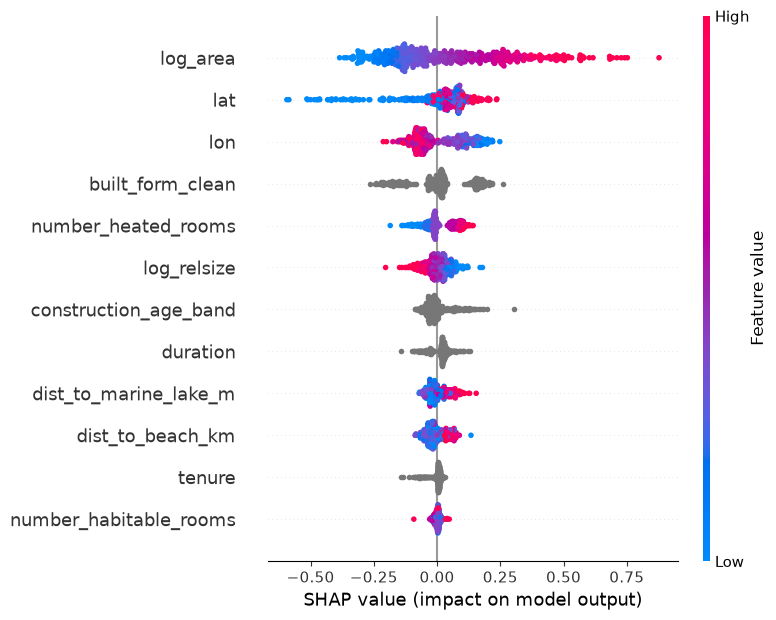

In [13]:
shap.summary_plot(shap_values, sample[ext_features], show=True)


### 3. Sanity checks — has it learned sensible things?

A tidy equation let us eyeball whether the model believed something daft.
With hundreds of trees we check it directly instead: hold everything about
a house constant, vary one feature, and confirm the prediction moves the
way common sense demands.

If any of these fail, something is wrong regardless of how good the test
score looks.


In [14]:
base_house = ext_test[ext_features].iloc[[0]].copy()

print("Check 1 - bigger houses should cost more:")
for area in [60, 80, 100, 130, 170]:
    probe = base_house.copy()
    probe["log_area"] = np.log(area)
    pred = np.exp(model_lgb_ext.predict(probe)[0])
    print(f"  {area:3d} m2 -> GBP {pred:>9,.0f}")

print()
print("Check 2 - detached should beat semi, which should beat terrace:")
for form in ["Detached", "Semi-Detached", "End-Terrace", "Mid-Terrace"]:
    probe = base_house.copy()
    probe["built_form_clean"] = pd.Categorical([form], categories=base_house["built_form_clean"].cat.categories)
    pred = np.exp(model_lgb_ext.predict(probe)[0])
    print(f"  {form:15s} -> GBP {pred:>9,.0f}")


Check 1 - bigger houses should cost more:
   60 m2 -> GBP   197,225
   80 m2 -> GBP   212,715
  100 m2 -> GBP   220,064
  130 m2 -> GBP   219,946
  170 m2 -> GBP   244,669

Check 2 - detached should beat semi, which should beat terrace:
  Detached        -> GBP   321,401
  Semi-Detached   -> GBP   267,818
  End-Terrace     -> GBP   258,559
  Mid-Terrace     -> GBP   258,140


## Keep the linear model too

Not deleting v3. The linear model stays as the readable companion — it can
still say "roughly, terraces go for 60% less than detached across Sefton",
which is quotable in a way a tree ensemble isn't.

More usefully: **when the two models disagree sharply about a specific
house, that disagreement is itself informative** — it usually means the
property is unusual in some way, which is exactly when a valuation deserves
a second look.


In [15]:
common = lgb_test.index.intersection(ext_test.index)
comparison = pd.DataFrame({
    "actual": np.exp(lgb_test.loc[common, "log_price_adj"]),
    "linear_v3": np.exp(m3.predict(sm.add_constant(lgb_test.loc[common, v3_features]))),
    "lightgbm_v4b": np.exp(pred_ext.loc[common]),
})
comparison["disagreement_pct"] = (
    (comparison["lightgbm_v4b"] - comparison["linear_v3"]).abs() / comparison["linear_v3"]
)
print(f"Median disagreement between the two models: {comparison['disagreement_pct'].median():.1%}")
print(f"Cases where they differ by more than 25%:   {(comparison['disagreement_pct'] > 0.25).mean():.1%}")
print()
print("Biggest disagreements - worth a manual look:")
print(comparison.nlargest(5, "disagreement_pct").to_string(
    formatters={c: "{:,.0f}".format for c in ["actual", "linear_v3", "lightgbm_v4b"]}))


Median disagreement between the two models: 13.5%
Cases where they differ by more than 25%:   22.2%

Biggest disagreements - worth a manual look:
       actual linear_v3 lightgbm_v4b  disagreement_pct
57671 256,444   115,424      319,534          1.768346
58464 289,764   111,861      274,960          1.458060
58143 214,576    82,902      184,612          1.226873
55889 189,674    94,205      204,590          1.171758
58705 202,146   107,031      232,016          1.167740
